# Outlier Detection for Histopathology Patches

This notebook provides a modular workflow to detect and review outlier patches in `train`, `val`, and `test` splits.

**Data convention.** Patches are stored as **CHW** tensors; pixel values are treated as **float in \([0,1]\)**. Helpers (`read_patch`, statistics, thresholds) assume this scale. If a file is `uint8` or clearly 0–255 (`max > 1.5`), a single division by 255 is applied when loading; otherwise no extra normalization.

## Goals
- Compare several outlier detection methods from simple to more expensive.
- Run each method on **N patches** per split or the full split (`N=None`).
- Save outlier outputs for each split with IDs and source path.
- Visualize outliers from worst to less severe for manual QA.
- Support manual overrides to keep or remove specific outliers.

## Output structure
- `outliers_outputs/<method_name>/<split>_scores.csv`
- `outliers_outputs/<method_name>/<split>_outliers.csv`
- `outliers_outputs/<method_name>/<split>_summary.json`
- `outliers_outputs/review/<method_name>/<split>_review.csv`

In [2]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import partial

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

## 1) Configuration

Edit only this section for paths, sampling, and output folders.

In [3]:
@dataclass
class SplitPaths:
    """Input paths for each dataset split."""

    train: str = 'train.h5'
    val: str = 'val.h5'
    test: str = 'test.h5'


@dataclass
class RunOptions:
    """Global options shared by all methods."""

    max_items_per_split: Optional[int] = None
    seed: int = 42
    out_dir: str = 'outliers_outputs'

    # If True, run train/val/test in parallel for per-split methods.
    parallel_splits: bool = False

    # Total thread budget for method C intra-split readers; see allocate_intra_split_workers.
    # If None, use os.cpu_count() (fallback 4).
    split_workers: Optional[int] = None

    # Max patch IDs per sub-task inside method C (smaller → better load balancing).
    method_c_batch_size: int = 256


SPLIT_PATHS = SplitPaths()
RUN_OPTIONS = RunOptions(
    max_items_per_split=None,  # Integer = subsample per split; None = full split.
    seed=42,
    out_dir='outliers_outputs',
    parallel_splits=True,
    split_workers=8,
    method_c_batch_size=1000,
)


def ensure_dir(path: str) -> None:
    """Create directory if it does not exist."""

    os.makedirs(path, exist_ok=True)


ensure_dir(RUN_OPTIONS.out_dir)
print('Output folder:', RUN_OPTIONS.out_dir)

Output folder: outliers_outputs


## 2) Shared utilities

These helpers are reused by all outlier methods. Intensities are handled in **\([0,1]\)** (see intro).

In [4]:
def load_ids(h5_path: str) -> List[str]:
    """Return all patch IDs from one H5 file."""

    with h5py.File(h5_path, 'r') as f:
        return list(f.keys())


def sample_ids(ids: List[str], max_items: Optional[int], seed: int) -> List[str]:
    """Return a random subset of IDs if max_items is provided."""

    if max_items is None or max_items >= len(ids):
        return ids
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(ids), size=max_items, replace=False)
    return [ids[i] for i in idx]


def allocate_intra_split_workers(total_workers: int) -> Dict[str, int]:
    """Split thread budget across train/val/test with priority on train.

    For ``N >= 3``: test=1, val=1, train=N-2 (e.g. N=4 -> train 2, val 1, test 1).
    For ``N == 2``: all splits get 1 worker (sum may exceed 2 if all run in parallel).
    For ``N == 1``: all splits get 1 (sequential use).
    """

    n = max(1, int(total_workers))
    if n == 1:
        return {'train': 1, 'val': 1, 'test': 1}
    if n == 2:
        return {'train': 1, 'val': 1, 'test': 1}
    return {'train': max(1, n - 2), 'val': 1, 'test': 1}


def _to_hwc_float01(x: np.ndarray, patch_id: str) -> np.ndarray:
    """Layout: CHW→HWC, optional 1→3 channels. Values in [0, 1] float.

    No rescaling for float inputs beyond clipping to [0, 1]. If storage is ``uint8``
    or values clearly lie in 0..255 (max > 1.5), divide by 255 once.
    """

    if x.ndim != 3:
        raise ValueError(f'Unexpected patch shape for ID {patch_id}: {x.shape}')

    if x.shape[0] in (1, 3):
        x = np.moveaxis(x, 0, -1)

    if x.shape[-1] == 1:
        x = np.repeat(x, repeats=3, axis=-1)

    x = np.asarray(x)
    if x.dtype == np.uint8 or float(np.nanmax(x)) > 1.5:
        x = x.astype(np.float32) / 255.0
    else:
        x = x.astype(np.float32)

    return np.clip(x, 0.0, 1.0)


def read_patch_from_handle(h5_file: h5py.File, patch_id: str) -> np.ndarray:
    """Read one patch from an open H5 handle: HWC float32 in [0, 1]."""

    x = np.array(h5_file[patch_id]['img'])
    return _to_hwc_float01(x, patch_id)


def read_patch(h5_path: str, patch_id: str) -> np.ndarray:
    """Read one patch as HWC float32 in [0, 1] (layout + dtype only)."""

    with h5py.File(h5_path, 'r') as f:
        return read_patch_from_handle(f, patch_id)


def read_metadata_center_from_handle(h5_file: h5py.File, patch_id: str) -> int:
    """Read center id from metadata[0], fallback to -1 if unavailable."""

    grp = h5_file[patch_id]
    if 'metadata' not in grp:
        return -1
    m = np.array(grp['metadata']).reshape(-1)
    if m.size == 0:
        return -1
    return int(m[0])


def read_metadata_center(h5_path: str, patch_id: str) -> int:
    """Read center id from metadata[0], fallback to -1 if unavailable."""

    with h5py.File(h5_path, 'r') as f:
        return read_metadata_center_from_handle(f, patch_id)


def rgb_to_gray(img: np.ndarray) -> np.ndarray:
    """Convert RGB image to float grayscale in [0, 1]."""

    imgf = img.astype(np.float32)
    return 0.299 * imgf[..., 0] + 0.587 * imgf[..., 1] + 0.114 * imgf[..., 2]


def channel_stats(img: np.ndarray) -> Dict[str, float]:
    """Compute robust intensity statistics for one patch in 0..1 space."""

    gray = rgb_to_gray(img)
    p1 = float(np.percentile(gray, 1))
    p99 = float(np.percentile(gray, 99))
    std = float(np.std(gray))

    hist, _ = np.histogram(gray, bins=64, range=(0.0, 1.0), density=False)
    hist = hist + 1e-12
    hist = hist / hist.sum()
    entropy = float(-(hist * np.log(hist)).sum())

    p_black = float(np.mean(gray <= 0.02))
    p_white = float(np.mean(gray >= 0.98))

    return {
        'gray_p1': p1,
        'gray_p99': p99,
        'gray_range_p99_p1': p99 - p1,
        'gray_std': std,
        'gray_entropy': entropy,
        'p_black': p_black,
        'p_white': p_white,
    }


def od_tissue_fraction(img: np.ndarray, od_thr: float = 0.15) -> float:
    """Tissue fraction from per-channel ``-log(intensity)`` on [0, 1] RGB (clamped).

    Higher ``od_sum`` indicates darker / more absorbing pixels (typical tissue vs bright background).
    """

    x = np.clip(img.astype(np.float32), 1e-6, 1.0)
    od = -np.log(x)
    od_sum = od.sum(axis=-1)
    return float(np.mean(od_sum > od_thr))


def gradient_energy(gray: np.ndarray) -> float:
    """Compute edge/texture energy from finite differences."""

    gx = np.abs(np.diff(gray, axis=1))
    gy = np.abs(np.diff(gray, axis=0))
    return float((gx.mean() + gy.mean()) / 2.0)


def colorfulness(img: np.ndarray) -> float:
    """Hasler–Süsstrunk-style colorfulness on RGB in [0, 1]."""

    r = img[..., 0].astype(np.float32)
    g = img[..., 1].astype(np.float32)
    b = img[..., 2].astype(np.float32)

    rg = np.abs(r - g)
    yb = np.abs(0.5 * (r + g) - b)

    std_rg = np.std(rg)
    std_yb = np.std(yb)
    mean_rg = np.mean(rg)
    mean_yb = np.mean(yb)

    return float(np.sqrt(std_rg ** 2 + std_yb ** 2) + 0.3 * np.sqrt(mean_rg ** 2 + mean_yb ** 2))


def build_base_table(split_name: str, h5_path: str, ids: List[str]) -> pd.DataFrame:
    """Create a base dataframe with split metadata.

    This function opens the H5 file once for faster center lookup.
    """

    rows = []
    with h5py.File(h5_path, 'r') as f:
        for patch_id in ids:
            rows.append(
                {
                    'split': split_name,
                    'h5_path': h5_path,
                    'patch_id': str(patch_id),
                    'center_id': read_metadata_center_from_handle(f, patch_id),
                }
            )
    return pd.DataFrame(rows)


def save_method_outputs(method_name: str, split_name: str, df: pd.DataFrame, out_dir: str) -> Dict[str, Any]:
    """Save full scores, outlier subset, and summary for one split."""

    method_dir = os.path.join(out_dir, method_name)
    ensure_dir(method_dir)

    scores_path = os.path.join(method_dir, f'{split_name}_scores.csv')
    outliers_path = os.path.join(method_dir, f'{split_name}_outliers.csv')
    summary_path = os.path.join(method_dir, f'{split_name}_summary.json')

    df_sorted = df.sort_values('score', ascending=False).reset_index(drop=True)
    df_sorted['rank_worst_first'] = np.arange(1, len(df_sorted) + 1)

    outliers = df_sorted[df_sorted['is_outlier']].copy()

    summary = {
        'method': method_name,
        'split': split_name,
        'n_total': int(len(df_sorted)),
        'n_outliers': int(len(outliers)),
        'outlier_ratio': float(len(outliers) / max(len(df_sorted), 1)),
        'score_mean': float(df_sorted['score'].mean()),
        'score_std': float(df_sorted['score'].std(ddof=0)),
        'score_q95': float(df_sorted['score'].quantile(0.95)),
        'score_q99': float(df_sorted['score'].quantile(0.99)),
    }

    df_sorted.to_csv(scores_path, index=False)
    outliers.to_csv(outliers_path, index=False)
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    return {
        'scores_path': scores_path,
        'outliers_path': outliers_path,
        'summary_path': summary_path,
        'summary': summary,
    }


def print_summary_table(summaries: List[Dict[str, Any]]) -> pd.DataFrame:
    """Display compact summary table across splits."""

    rows = [s['summary'] for s in summaries]
    df = pd.DataFrame(rows)
    display(df)
    return df

## 3) Method A (fast): Black/White extremes + low entropy

This method targets obvious invalid patches (all black, all white, almost constant images).

In [4]:
def detect_outliers_method_a(
    split_name: str,
    h5_path: str,
    max_items: Optional[int],
    seed: int,
    p_black_thr: float = 0.90,
    p_white_thr: float = 0.90,
    min_entropy: float = 2.5,
    min_range: float = 0.08,
    **kwargs: Any,
) -> pd.DataFrame:
    """Detect outliers using simple intensity and entropy thresholds.

    Score is higher for more severe outlier behavior.
    """

    ids = sample_ids(load_ids(h5_path), max_items=max_items, seed=seed)
    base = build_base_table(split_name, h5_path, ids)

    rows = []
    with h5py.File(h5_path, 'r') as f:
        for patch_id in tqdm(ids, desc=f'Method A - {split_name}', leave=False):
            img = read_patch_from_handle(f, patch_id)
            st = channel_stats(img)

            score = (
                3.0 * max(0.0, st['p_black'] - p_black_thr)
                + 3.0 * max(0.0, st['p_white'] - p_white_thr)
                + 2.0 * max(0.0, min_entropy - st['gray_entropy'])
                + 2.0 * max(0.0, min_range - st['gray_range_p99_p1']) / max(min_range, 1e-6)
            )

            is_outlier = (
                (st['p_black'] >= p_black_thr)
                or (st['p_white'] >= p_white_thr)
                or (st['gray_entropy'] <= min_entropy)
                or (st['gray_range_p99_p1'] <= min_range)
            )

            rows.append(
                {
                    'patch_id': patch_id,
                    'score': float(score),
                    'is_outlier': bool(is_outlier),
                    **st,
                }
            )

    df = base.merge(pd.DataFrame(rows), on='patch_id', how='left')
    return df

## 4) Method B (still fast): OD tissue fraction + texture

This method separates empty/background or collapsed patches from textured tissue.

In [5]:
def detect_outliers_method_b(
    split_name: str,
    h5_path: str,
    max_items: Optional[int],
    seed: int,
    min_tissue_frac: float = 0.01,
    max_tissue_frac: float = 0.995,
    min_grad_energy: float = 0.01,
    **kwargs: Any,
) -> pd.DataFrame:
    """Detect outliers with OD tissue fraction and edge/texture checks."""

    ids = sample_ids(load_ids(h5_path), max_items=max_items, seed=seed)
    base = build_base_table(split_name, h5_path, ids)

    rows = []
    with h5py.File(h5_path, 'r') as f:
        for patch_id in tqdm(ids, desc=f'Method B - {split_name}', leave=False):
            img = read_patch_from_handle(f, patch_id)
            gray = rgb_to_gray(img)

            tissue_frac = od_tissue_fraction(img)
            grad = gradient_energy(gray)
            st = channel_stats(img)

            low_texture = grad < min_grad_energy
            tissue_extreme = (tissue_frac < min_tissue_frac) or (tissue_frac > max_tissue_frac)

            score = (
                2.5 * max(0.0, min_tissue_frac - tissue_frac)
                + 2.5 * max(0.0, tissue_frac - max_tissue_frac)
                + 1.5 * max(0.0, min_grad_energy - grad) / max(min_grad_energy, 1e-6)
                + 1.0 * st['p_black']
                + 1.0 * st['p_white']
            )

            is_outlier = bool(tissue_extreme or low_texture)

            rows.append(
                {
                    'patch_id': patch_id,
                    'score': float(score),
                    'is_outlier': is_outlier,
                    'tissue_frac_od': float(tissue_frac),
                    'grad_energy': float(grad),
                    **st,
                }
            )

    return base.merge(pd.DataFrame(rows), on='patch_id', how='left')

## 5) Method C: Color + texture scoring

This method is useful when dark purple tissue must be separated from true black artifacts.

**Parallelism:** `RunOptions.split_workers` sets a **total** thread budget; `allocate_intra_split_workers` gives **train** the remainder after reserving 1 thread each for val and test (e.g. 4 → train 2, val 1, test 1). `run_per_split_method` passes `intra_split_workers` and `method_c_batch_size` into method C.

**Filtre « blanc visuel » (2 + 1 paramètres).** Un pixel est *blanc visuel* ssi **(1)** son gris Rec.601 est `>= white_gray_min` (**souple**, typ. `0.82`–`0.90`, bien en dessous du quasi-blanc dur `0.98` de `p_white`) **et** **(2)** sa saturation locale RGB `(max-min)/(max+eps)` est `<= white_max_sat` (fond clair peu chromatique ; le tissu coloré sort du masque). La colonne `p_soft_white` est la **fraction** de tels pixels. **(3)** `max_white_frac` : part **maximale** de `p_soft_white` pour que le patch **reste** outlier ; si `p_soft_white > max_white_frac`, il **n’est pas** outlier. `max_white_frac=1.0` désactive le filtre. **Exemples** `(white_gray_min, white_max_sat, max_white_frac)` : `(0.86, 0.28, 0.80)` équilibré ; `(0.84, 0.35, 0.85)` plus tolérant sur le « blanc » ; `(0.88, 0.22, 0.72)` plus strict. `white_max_sat=1.0` → seul le gris compte (comme avant). La grille partage `white_gray_min` et `white_max_sat` sur une passe H5 : `run_per_split_method_c_grid(..., white_gray_min=0.86, white_max_sat=0.28)`.

In [5]:
def hsv_saturation_mean(img: np.ndarray) -> float:
    """Approximate saturation from RGB in [0, 1] (no extra scaling)."""

    x = img.astype(np.float32)
    mx = np.max(x, axis=-1)
    mn = np.min(x, axis=-1)
    sat = np.where(mx > 0, (mx - mn) / (mx + 1e-8), 0.0)
    return float(np.mean(sat))


def _rgb_local_saturation_map(img: np.ndarray) -> np.ndarray:
    """Per-pixel saturation in [0, 1], same formula as ``hsv_saturation_mean`` but HxW."""

    x = img.astype(np.float32)
    mx = np.max(x, axis=-1)
    mn = np.min(x, axis=-1)
    return np.where(mx > 0, (mx - mn) / (mx + 1e-8), 0.0)


def _method_c_row_from_img(
    patch_id: str,
    img: np.ndarray,
    *,
    white_gray_min: float,
    white_max_sat: float,
) -> Dict[str, Any]:
    gray = rgb_to_gray(img)
    sat = hsv_saturation_mean(img)
    cful = colorfulness(img)
    grad = gradient_energy(gray)
    st = channel_stats(img)
    gmin = float(white_gray_min)
    smax = float(white_max_sat)
    sat_px = _rgb_local_saturation_map(img)
    if smax >= 1.0 - 1e-9:
        soft_mask = gray >= gmin
    else:
        soft_mask = (gray >= gmin) & (sat_px <= smax)
    p_soft_white = float(np.mean(soft_mask))
    return {
        'patch_id': patch_id,
        'sat_mean': float(sat),
        'colorfulness': float(cful),
        'grad_energy': float(grad),
        'p_soft_white': p_soft_white,
        **st,
    }


def _method_c_chunk_worker(
    h5_path: str,
    patch_ids: List[str],
    *,
    white_gray_min: float,
    white_max_sat: float,
) -> List[Dict[str, Any]]:
    """Read a disjoint ID list with one File handle (thread-safe vs other handles)."""

    rows: List[Dict[str, Any]] = []
    with h5py.File(h5_path, 'r') as f:
        for patch_id in patch_ids:
            img = read_patch_from_handle(f, patch_id)
            rows.append(
                _method_c_row_from_img(
                    patch_id,
                    img,
                    white_gray_min=white_gray_min,
                    white_max_sat=white_max_sat,
                )
            )
    return rows


def extract_method_c_features(
    h5_path: str,
    ids: List[str],
    intra_split_workers: int = 1,
    method_c_batch_size: int = 256,
    desc: str = 'Method C features',
    white_gray_min: float = 0.86,
    white_max_sat: float = 0.28,
) -> pd.DataFrame:
    """One H5 pass: saturation, colorfulness, gradient, channel_stats, ``p_soft_white`` (no score thresholds).

    ``p_soft_white``: fraction of pixels that are *visually white* — Rec.601 ``gray >= white_gray_min``
    and per-pixel RGB saturation ``<= white_max_sat`` (unless ``white_max_sat >= 1``, then luminance only).
    Use with ``max_white_frac`` in ``method_c_apply_thresholds``.

    IDs are split across ``intra_split_workers`` contiguous ranges, then into sub-batches
    of at most ``method_c_batch_size`` so idle threads can pick work as chunks finish.
    """

    if not ids:
        return pd.DataFrame()

    w = max(1, int(intra_split_workers))
    bs = max(1, int(method_c_batch_size))

    bounds = np.linspace(0, len(ids), w + 1, dtype=int)
    partitions = [ids[bounds[i] : bounds[i + 1]] for i in range(w) if bounds[i] < bounds[i + 1]]
    tasks: List[List[str]] = []
    for part in partitions:
        for j in range(0, len(part), bs):
            tasks.append(part[j : j + bs])

    chunk = partial(
        _method_c_chunk_worker,
        white_gray_min=float(white_gray_min),
        white_max_sat=float(white_max_sat),
    )

    if w == 1:
        rows_one: List[Dict[str, Any]] = []
        for t in tqdm(tasks, desc=desc, leave=False):
            rows_one.extend(chunk(h5_path, t))
        return pd.DataFrame(rows_one)

    rows_by_i: List[Optional[List[Dict[str, Any]]]] = [None] * len(tasks)
    with ThreadPoolExecutor(max_workers=w) as ex:
        futs = {ex.submit(chunk, h5_path, t): idx for idx, t in enumerate(tasks)}
        for fut in tqdm(as_completed(futs), total=len(futs), desc=desc, leave=False):
            idx = futs[fut]
            rows_by_i[idx] = fut.result()

    ordered: List[Dict[str, Any]] = []
    for part in rows_by_i:
        if part:
            ordered.extend(part)
    return pd.DataFrame(ordered)


def method_c_apply_thresholds(
    feat_df: pd.DataFrame,
    min_sat_mean: float = 0.03,
    min_colorfulness: float = 0.03,
    min_grad_energy: float = 0.01,
    max_white_frac: float = 1.0,
) -> pd.DataFrame:
    """Vectorized score + is_outlier from a feature table (method C rules).

    ``p_soft_white`` (from extraction) is the fraction of *visually white* pixels
    (see ``extract_method_c_features``). A patch is an outlier only if the usual
    color/texture rules hold **and** ``p_soft_white <= max_white_frac``.
    If that fraction exceeds ``max_white_frac``, the patch is **not** flagged.
    ``max_white_frac=1.0`` disables this filter.

    Legacy columns: ``p_soft_white``, else ``p_visual_white``, else ``p_bright``, else ``p_white``.
    """

    if feat_df.empty:
        return feat_df.copy()

    sat = feat_df['sat_mean'].to_numpy(dtype=np.float64)
    cful = feat_df['colorfulness'].to_numpy(dtype=np.float64)
    grad = feat_df['grad_energy'].to_numpy(dtype=np.float64)
    pb = feat_df['p_black'].to_numpy(dtype=np.float64)
    if 'p_soft_white' in feat_df.columns:
        pv = feat_df['p_soft_white'].to_numpy(dtype=np.float64)
    elif 'p_visual_white' in feat_df.columns:
        pv = feat_df['p_visual_white'].to_numpy(dtype=np.float64)
    elif 'p_bright' in feat_df.columns:
        pv = feat_df['p_bright'].to_numpy(dtype=np.float64)
    else:
        pv = feat_df['p_white'].to_numpy(dtype=np.float64)

    score = (
        2.0 * np.maximum(0.0, min_sat_mean - sat) / max(min_sat_mean, 1e-6)
        + 2.0 * np.maximum(0.0, min_colorfulness - cful) / max(min_colorfulness, 1e-6)
        + 1.0 * np.maximum(0.0, min_grad_energy - grad) / max(min_grad_energy, 1e-6)
        + 1.5 * pb
    )
    base_out = ((sat < min_sat_mean) & (cful < min_colorfulness)) | (grad < min_grad_energy)
    is_out = base_out & (pv <= float(max_white_frac))

    out = feat_df.copy()
    out['score'] = score.astype(np.float64)
    out['is_outlier'] = is_out.astype(bool)
    return out


def sweep_method_c_params(
    feat_df: pd.DataFrame,
    param_grid: List[Dict[str, Any]],
) -> Dict[str, pd.DataFrame]:
    """Try many threshold triplets on one feature table.

    Each item in ``param_grid`` is a dict with keys ``min_sat_mean``, ``min_colorfulness``,
    ``min_grad_energy``, and optionally ``name`` (used as result key; default ``cfg_i``),
    and optionally ``max_white_frac`` (default ``1.0``; legacy ``max_visual_white_frac``, ``max_bright_frac``).
    """

    results: Dict[str, pd.DataFrame] = {}
    for i, cfg in enumerate(param_grid):
        name = str(cfg.get('name', f'cfg_{i}'))
        mv = cfg.get('max_white_frac', cfg.get('max_visual_white_frac', cfg.get('max_bright_frac', 1.0)))
        results[name] = method_c_apply_thresholds(
            feat_df,
            min_sat_mean=float(cfg['min_sat_mean']),
            min_colorfulness=float(cfg['min_colorfulness']),
            min_grad_energy=float(cfg['min_grad_energy']),
            max_white_frac=float(mv),
        )
    return results


@dataclass
class MethodCParamSweep:
    """Hold feature rows once, then apply many (min_sat, min_colorfulness, min_grad) configs."""

    features: pd.DataFrame

    def apply(
        self,
        min_sat_mean: float,
        min_colorfulness: float,
        min_grad_energy: float,
        max_white_frac: float = 1.0,
    ) -> pd.DataFrame:
        return method_c_apply_thresholds(
            self.features,
            min_sat_mean=min_sat_mean,
            min_colorfulness=min_colorfulness,
            min_grad_energy=min_grad_energy,
            max_white_frac=max_white_frac,
        )

    def grid(self, param_grid: List[Dict[str, Any]]) -> Dict[str, pd.DataFrame]:
        return sweep_method_c_params(self.features, param_grid)


def detect_outliers_method_c(
    split_name: str,
    h5_path: str,
    max_items: Optional[int],
    seed: int,
    min_sat_mean: float = 0.03,
    min_colorfulness: float = 0.03,
    min_grad_energy: float = 0.01,
    white_gray_min: float = 0.86,
    white_max_sat: float = 0.28,
    max_white_frac: float = 1.0,
    intra_split_workers: int = 1,
    method_c_batch_size: int = 256,
    **kwargs: Any,
) -> pd.DataFrame:
    """Detect outliers using colorfulness, saturation, and texture.

    ``white_gray_min`` / ``white_max_sat``: define *visually white* pixels for ``p_soft_white``.
    ``max_white_frac``: max allowed ``p_soft_white`` for ``is_outlier``; see ``method_c_apply_thresholds``.
    ``intra_split_workers``: parallel H5 readers for this split (see ``allocate_intra_split_workers``).
    ``method_c_batch_size``: max patch IDs per sub-task (smaller → more load-balancing across workers).
    """

    ids = sample_ids(load_ids(h5_path), max_items=max_items, seed=seed)
    base = build_base_table(split_name, h5_path, ids)

    feat_df = extract_method_c_features(
        h5_path,
        ids,
        intra_split_workers=intra_split_workers,
        method_c_batch_size=method_c_batch_size,
        desc=f'Method C features - {split_name}',
        white_gray_min=float(white_gray_min),
        white_max_sat=float(white_max_sat),
    )
    scored = method_c_apply_thresholds(
        feat_df,
        min_sat_mean=min_sat_mean,
        min_colorfulness=min_colorfulness,
        min_grad_energy=min_grad_energy,
        max_white_frac=max_white_frac,
    )
    return base.merge(scored, on='patch_id', how='left')


def detect_outliers_method_c_grid(
    split_name: str,
    h5_path: str,
    max_items: Optional[int],
    seed: int,
    param_grid: List[Dict[str, Any]],
    intra_split_workers: int = 1,
    method_c_batch_size: int = 256,
    white_gray_min: float = 0.86,
    white_max_sat: float = 0.28,
) -> Dict[str, pd.DataFrame]:
    """Method C: several threshold configs after **one** feature pass (no extra H5 reads).

    Each ``param_grid`` item needs ``name``, ``min_sat_mean``, ``min_colorfulness``,
    ``min_grad_energy``. Optional: ``max_white_frac`` (default ``1.0``; legacy ``max_visual_white_frac``).
    ``white_gray_min`` and ``white_max_sat`` apply to the shared feature pass (same for all grid configs).
    Returns ``{name: dataframe}`` for this split.
    """

    ids = sample_ids(load_ids(h5_path), max_items=max_items, seed=seed)
    base = build_base_table(split_name, h5_path, ids)
    feat_df = extract_method_c_features(
        h5_path,
        ids,
        intra_split_workers=intra_split_workers,
        method_c_batch_size=method_c_batch_size,
        desc=f'Method C grid features - {split_name}',
        white_gray_min=float(white_gray_min),
        white_max_sat=float(white_max_sat),
    )
    out: Dict[str, pd.DataFrame] = {}
    for i, cfg in enumerate(param_grid):
        name = str(cfg.get('name', f'cfg_{i}'))
        mv = cfg.get('max_white_frac', cfg.get('max_visual_white_frac', cfg.get('max_bright_frac', 1.0)))
        scored = method_c_apply_thresholds(
            feat_df,
            min_sat_mean=float(cfg['min_sat_mean']),
            min_colorfulness=float(cfg['min_colorfulness']),
            min_grad_energy=float(cfg['min_grad_energy']),
            max_white_frac=float(mv),
        )
        out[name] = base.merge(scored, on='patch_id', how='left')
    return out


## 6) Method D (moderate): Isolation Forest on handcrafted features

Fit on train features, then score train/val/test with the same detector.

In [7]:
FEATURE_COLS_D = [
    'p_black',
    'p_white',
    'gray_std',
    'gray_entropy',
    'gray_range_p99_p1',
    'tissue_frac_od',
    'grad_energy',
    'sat_mean',
    'colorfulness',
]


def extract_features_for_method_d(h5_path: str, ids: List[str], desc: str) -> pd.DataFrame:
    """Extract handcrafted feature table used by Isolation Forest."""

    rows = []
    for patch_id in tqdm(ids, desc=desc, leave=False):
        img = read_patch(h5_path, patch_id)
        gray = rgb_to_gray(img)
        st = channel_stats(img)
        rows.append(
            {
                'patch_id': patch_id,
                'tissue_frac_od': od_tissue_fraction(img),
                'grad_energy': gradient_energy(gray),
                'sat_mean': hsv_saturation_mean(img),
                'colorfulness': colorfulness(img),
                **st,
            }
        )
    return pd.DataFrame(rows)


def detect_outliers_method_d(
    split_paths: SplitPaths,
    max_items_per_split: Optional[int],
    seed: int,
    contamination: float = 0.02,
) -> Dict[str, pd.DataFrame]:
    """Run Isolation Forest with train-fitted scaling and model."""

    split_to_ids = {
        'train': sample_ids(load_ids(split_paths.train), max_items_per_split, seed),
        'val': sample_ids(load_ids(split_paths.val), max_items_per_split, seed),
        'test': sample_ids(load_ids(split_paths.test), max_items_per_split, seed),
    }

    feats = {
        'train': extract_features_for_method_d(split_paths.train, split_to_ids['train'], 'Method D features - train'),
        'val': extract_features_for_method_d(split_paths.val, split_to_ids['val'], 'Method D features - val'),
        'test': extract_features_for_method_d(split_paths.test, split_to_ids['test'], 'Method D features - test'),
    }

    scaler = RobustScaler()
    x_train = scaler.fit_transform(feats['train'][FEATURE_COLS_D].values)

    detector = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=seed,
        n_jobs=-1,
    )
    detector.fit(x_train)

    out = {}
    for split_name in ['train', 'val', 'test']:
        x = scaler.transform(feats[split_name][FEATURE_COLS_D].values)
        # Higher score = more abnormal
        score = -detector.score_samples(x)

        threshold = np.quantile(score, 1.0 - contamination)
        is_outlier = score >= threshold

        base = build_base_table(split_name, getattr(split_paths, split_name), split_to_ids[split_name])
        tmp = feats[split_name].copy()
        tmp['score'] = score.astype(float)
        tmp['is_outlier'] = is_outlier.astype(bool)

        out[split_name] = base.merge(tmp, on='patch_id', how='left')

    return out

## 7) Method E (expensive): DINO embedding distance

This optional method is slower because it computes deep features. It is useful for harder visual anomalies.

Set `max_items_per_split` to a small value first for debugging.

In [8]:
import torch
import torchvision.transforms as T


def load_dino_backbone(backbone_name: str = 'dinov2_vits14') -> torch.nn.Module:
    """Load a frozen DINOv2 backbone."""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = torch.hub.load('facebookresearch/dinov2', backbone_name).to(device)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model


def build_dino_transform(size: Tuple[int, int] = (224, 224)) -> Any:
    """Build image transform for DINO embedding extraction."""

    return T.Compose(
        [
            T.ToPILImage(),
            T.Resize(size),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )


def extract_dino_embeddings(
    h5_path: str,
    ids: List[str],
    model: torch.nn.Module,
    tfm: Any,
    batch_size: int = 64,
    desc: str = 'DINO embeddings',
) -> Tuple[List[str], np.ndarray]:
    """Extract DINO embeddings for a list of patch IDs."""

    device = next(model.parameters()).device

    feats = []
    valid_ids = []
    batch_imgs = []
    batch_ids = []

    def flush_batch() -> None:
        if not batch_imgs:
            return
        x = torch.stack(batch_imgs, dim=0).to(device)
        with torch.no_grad():
            z = model(x).detach().cpu().numpy()
        feats.append(z)
        valid_ids.extend(batch_ids)
        batch_imgs.clear()
        batch_ids.clear()

    for patch_id in tqdm(ids, desc=desc, leave=False):
        img = read_patch(h5_path, patch_id)
        tensor = tfm(img)
        batch_imgs.append(tensor)
        batch_ids.append(patch_id)
        if len(batch_imgs) >= batch_size:
            flush_batch()

    flush_batch()

    if not feats:
        return [], np.empty((0, 0), dtype=np.float32)

    emb = np.concatenate(feats, axis=0).astype(np.float32)
    return valid_ids, emb


def robust_mahalanobis(x: np.ndarray, mu: np.ndarray, inv_cov: np.ndarray) -> np.ndarray:
    """Compute squared Mahalanobis distance."""

    xc = x - mu[None, :]
    return np.einsum('bi,ij,bj->b', xc, inv_cov, xc)


def detect_outliers_method_e(
    split_paths: SplitPaths,
    max_items_per_split: Optional[int],
    seed: int,
    contamination: float = 0.02,
    backbone_name: str = 'dinov2_vits14',
    batch_size: int = 64,
) -> Dict[str, pd.DataFrame]:
    """Detect outliers with DINO embeddings and train-based distance model."""

    split_to_ids = {
        'train': sample_ids(load_ids(split_paths.train), max_items_per_split, seed),
        'val': sample_ids(load_ids(split_paths.val), max_items_per_split, seed),
        'test': sample_ids(load_ids(split_paths.test), max_items_per_split, seed),
    }

    model = load_dino_backbone(backbone_name=backbone_name)
    tfm = build_dino_transform((224, 224))

    emb = {}
    valid_ids = {}

    for split_name in ['train', 'val', 'test']:
        ids_ok, z = extract_dino_embeddings(
            h5_path=getattr(split_paths, split_name),
            ids=split_to_ids[split_name],
            model=model,
            tfm=tfm,
            batch_size=batch_size,
            desc=f'Method E embeddings - {split_name}',
        )
        emb[split_name] = z
        valid_ids[split_name] = ids_ok

    z_train = emb['train']
    mu = np.mean(z_train, axis=0)
    cov = np.cov(z_train, rowvar=False)
    cov = cov + 1e-3 * np.eye(cov.shape[0], dtype=np.float32)
    inv_cov = np.linalg.pinv(cov)

    out = {}
    for split_name in ['train', 'val', 'test']:
        d2 = robust_mahalanobis(emb[split_name], mu, inv_cov)
        threshold = np.quantile(d2, 1.0 - contamination)
        is_outlier = d2 >= threshold

        base = build_base_table(split_name, getattr(split_paths, split_name), valid_ids[split_name])
        tmp = pd.DataFrame(
            {
                'patch_id': valid_ids[split_name],
                'score': d2.astype(float),
                'is_outlier': is_outlier.astype(bool),
            }
        )

        out[split_name] = base.merge(tmp, on='patch_id', how='left')

    return out

## 8) Unified runners and saving

- ``run_per_split_method`` — single-config per-split methods (saves CSVs).
- ``run_per_split_method_c_grid`` — method C only: **one H5 pass per split**, all named configs, train/val/test in parallel when ``parallel_splits``; **no** automatic save (returns `outputs_by_config` + `summary_df`).

In [7]:
from IPython.display import display


def run_per_split_method(
    method_name: str,
    method_fn,
    split_paths: SplitPaths,
    options: RunOptions,
    method_kwargs: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """Run a method that processes each split independently.

    If ``options.parallel_splits`` is True, train/val/test run as three concurrent jobs.
    Per-split H5 parallelism (method C): ``options.split_workers`` is the total thread
    budget split with ``allocate_intra_split_workers`` (train gets the remainder after
    val=1 and test=1 when N>=3).
    """

    method_kwargs = method_kwargs or {}
    split_to_path = {'train': split_paths.train, 'val': split_paths.val, 'test': split_paths.test}

    budget = options.split_workers
    if budget is None:
        budget = max(1, int(os.cpu_count() or 4))
    alloc = allocate_intra_split_workers(budget)

    all_summaries = []
    all_outputs = {}

    def _run_one(split_name: str, h5_path: str):
        df = method_fn(
            split_name=split_name,
            h5_path=h5_path,
            max_items=options.max_items_per_split,
            seed=options.seed,
            intra_split_workers=alloc[split_name],
            method_c_batch_size=options.method_c_batch_size,
            **method_kwargs,
        )
        out = save_method_outputs(method_name, split_name, df, options.out_dir)
        return split_name, out

    if options.parallel_splits:
        with ThreadPoolExecutor(max_workers=3) as ex:
            futs = [ex.submit(_run_one, split_name, h5_path) for split_name, h5_path in split_to_path.items()]
            for fut in as_completed(futs):
                split_name, out = fut.result()
                all_summaries.append(out)
                all_outputs[split_name] = out
    else:
        for split_name, h5_path in split_to_path.items():
            split_name, out = _run_one(split_name, h5_path)
            all_summaries.append(out)
            all_outputs[split_name] = out

    # Keep deterministic split order in summary.
    order = {'train': 0, 'val': 1, 'test': 2}
    all_summaries = sorted(all_summaries, key=lambda s: order.get(s['summary']['split'], 99))

    summary_df = print_summary_table(all_summaries)
    return {'method_name': method_name, 'outputs': all_outputs, 'summary_df': summary_df}


def run_per_split_method_c_grid(
    method_name_prefix: str,
    split_paths: SplitPaths,
    options: RunOptions,
    param_grid: List[Dict[str, Any]],
    white_gray_min: float = 0.86,
    white_max_sat: float = 0.28,
) -> Dict[str, Any]:
    """Method C multi-config: **one H5 pass per split**, then one DataFrame per named config.

    Same parallelism as ``run_per_split_method``: when ``parallel_splits`` is True, train/val/test
    run as three concurrent jobs (each job reads its split once, then applies all thresholds).
    Does **not** write CSVs; returns ``outputs_by_config`` and ``summary_df`` (also ``display``).
    """

    split_to_path = {'train': split_paths.train, 'val': split_paths.val, 'test': split_paths.test}
    budget = options.split_workers
    if budget is None:
        budget = max(1, int(os.cpu_count() or 4))
    alloc = allocate_intra_split_workers(budget)

    def _run_one(split_name: str, h5_path: str):
        dfs = detect_outliers_method_c_grid(
            split_name=split_name,
            h5_path=h5_path,
            max_items=options.max_items_per_split,
            seed=options.seed,
            param_grid=param_grid,
            intra_split_workers=alloc[split_name],
            method_c_batch_size=options.method_c_batch_size,
            white_gray_min=float(white_gray_min),
            white_max_sat=float(white_max_sat),
        )
        return split_name, dfs

    split_to_cfg_dfs: Dict[str, Dict[str, pd.DataFrame]] = {}
    if options.parallel_splits:
        with ThreadPoolExecutor(max_workers=3) as ex:
            futs = [ex.submit(_run_one, sn, hp) for sn, hp in split_to_path.items()]
            for fut in as_completed(futs):
                sn, dfs = fut.result()
                split_to_cfg_dfs[sn] = dfs
    else:
        for sn, hp in split_to_path.items():
            sn, dfs = _run_one(sn, hp)
            split_to_cfg_dfs[sn] = dfs

    cfg_names = list(split_to_cfg_dfs['train'].keys())
    outputs_by_config: Dict[str, Dict[str, pd.DataFrame]] = {name: {} for name in cfg_names}
    for split_name in ('train', 'val', 'test'):
        for cfg_name in cfg_names:
            outputs_by_config[cfg_name][split_name] = split_to_cfg_dfs[split_name][cfg_name]

    rows = []
    for cfg_name in cfg_names:
        for split_name in ('train', 'val', 'test'):
            df = outputs_by_config[cfg_name][split_name]
            df_sorted = df.sort_values('score', ascending=False).reset_index(drop=True)
            n = len(df_sorted)
            no = int(df_sorted['is_outlier'].sum())
            rows.append(
                {
                    'method': f'{method_name_prefix}_{cfg_name}',
                    'config': cfg_name,
                    'split': split_name,
                    'n_total': int(n),
                    'n_outliers': no,
                    'outlier_ratio': float(no / max(n, 1)),
                    'score_mean': float(df_sorted['score'].mean()),
                    'score_std': float(df_sorted['score'].std(ddof=0)),
                    'score_q95': float(df_sorted['score'].quantile(0.95)),
                    'score_q99': float(df_sorted['score'].quantile(0.99)),
                }
            )
    summary_df = pd.DataFrame(rows)
    display(summary_df.sort_values(['config', 'split']))

    return {
        'method_name_prefix': method_name_prefix,
        'param_grid': param_grid,
        'outputs_by_config': outputs_by_config,
        'split_to_cfg_dfs': split_to_cfg_dfs,
        'summary_df': summary_df,
    }


def run_global_method(
    method_name: str,
    global_fn,
    split_paths: SplitPaths,
    options: RunOptions,
    method_kwargs: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """Run a method that jointly uses train/val/test (fit on train, score all)."""

    method_kwargs = method_kwargs or {}
    split_to_df = global_fn(
        split_paths=split_paths,
        max_items_per_split=options.max_items_per_split,
        seed=options.seed,
        **method_kwargs,
    )

    all_summaries = []
    all_outputs = {}

    for split_name, df in split_to_df.items():
        out = save_method_outputs(method_name, split_name, df, options.out_dir)
        all_summaries.append(out)
        all_outputs[split_name] = out

    summary_df = print_summary_table(all_summaries)
    return {'method_name': method_name, 'outputs': all_outputs, 'summary_df': summary_df}

## 9) Visualization and manual review tools

Use these functions to inspect outliers and manually override false positives.

In [8]:
def load_scores(method_name: str, split_name: str, out_dir: str) -> pd.DataFrame:
    """Load saved scores for one method and split."""

    path = os.path.join(out_dir, method_name, f'{split_name}_scores.csv')
    return pd.read_csv(path)


def read_patch_label(h5_path: str, patch_id: str) -> float:
    """Read binary label from H5 if present; otherwise NaN."""

    with h5py.File(h5_path, 'r') as f:
        g = f[patch_id]
        if 'label' not in g:
            return float(np.nan)
        return float(np.array(g['label']).reshape(-1)[0])


def visualize_outliers(
    method_name: str,
    split_name: str,
    out_dir: str,
    min_k: int = 1,
    top_k: int = 36,
    only_flagged: bool = True,
    descending: bool = True,
    ncols: int = 6,
) -> pd.DataFrame:
    """Display outliers from worst to better based on score.

    Parameters
    - ``min_k``, ``top_k``: 1-based ranks in the sorted table (after optional outlier-only filter).
      Rows ``min_k`` through ``top_k`` inclusive are shown (e.g. ``min_k=10``, ``top_k=30`` → 21 patches, ranks 10–30).
    """

    df_full = load_scores(method_name, split_name, out_dir)
    n_outliers = int(df_full['is_outlier'].astype(bool).sum())
    print(f'Outliers flagged by method (split={split_name}): {n_outliers} / {len(df_full)}')

    df = df_full.copy()
    if only_flagged:
        df = df[df['is_outlier'] == True].copy()

    df = df.sort_values('score', ascending=not descending).reset_index(drop=True)

    if min_k < 1:
        raise ValueError('min_k must be >= 1')
    if top_k < min_k:
        raise ValueError('top_k must be >= min_k')

    df = df.iloc[min_k - 1 : top_k].reset_index(drop=True)
    print(f'Visualization slice: ranks {min_k}-{top_k} ({len(df)} patch(es))')

    if df.empty:
        print('No samples to visualize (empty slice).')
        return df

    if split_name in ('train', 'val'):
        df['label'] = [
            read_patch_label(str(row['h5_path']), str(row['patch_id']))
            for _, row in df.iterrows()
        ]
    else:
        df['label'] = np.nan

    n = len(df)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, (_, row) in enumerate(df.iterrows()):
        ax = axes[ax_idx]
        img = read_patch(row['h5_path'], str(row['patch_id']))
        ax.imshow(img)
        rank = min_k + ax_idx
        ax.set_title(f'#{rank} | ID={row["patch_id"]}\nscore={row["score"]:.4f}')
        ax.axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    show_cols = ['patch_id', 'score', 'is_outlier', 'center_id']
    if split_name in ('train', 'val'):
        show_cols = ['patch_id', 'label', 'score', 'is_outlier', 'center_id']

    display(df[show_cols].head(min(50, len(df))))
    return df


def save_manual_review(
    method_name: str,
    split_name: str,
    out_dir: str,
    keep_ids: Optional[List[str]] = None,
    remove_ids: Optional[List[str]] = None,
    note: str = '',
) -> str:
    """Save manual keep/remove decisions for one split.

    keep_ids means force non-outlier.
    remove_ids means force outlier.
    """

    keep_ids = keep_ids or []
    remove_ids = remove_ids or []

    review_dir = os.path.join(out_dir, 'review', method_name)
    ensure_dir(review_dir)

    rows = []
    for x in keep_ids:
        rows.append({'patch_id': str(x), 'decision': 'keep', 'note': note})
    for x in remove_ids:
        rows.append({'patch_id': str(x), 'decision': 'remove', 'note': note})

    review_path = os.path.join(review_dir, f'{split_name}_review.csv')
    pd.DataFrame(rows).drop_duplicates(subset=['patch_id'], keep='last').to_csv(review_path, index=False)
    return review_path


def apply_manual_review(method_name: str, split_name: str, out_dir: str) -> pd.DataFrame:
    """Apply review decisions and return updated score table."""

    scores_path = os.path.join(out_dir, method_name, f'{split_name}_scores.csv')
    review_path = os.path.join(out_dir, 'review', method_name, f'{split_name}_review.csv')

    scores = pd.read_csv(scores_path)
    if not os.path.exists(review_path):
        scores['is_outlier_final'] = scores['is_outlier'].astype(bool)
        return scores

    review = pd.read_csv(review_path)
    scores['is_outlier_final'] = scores['is_outlier'].astype(bool)

    keep_set = set(review.loc[review['decision'] == 'keep', 'patch_id'].astype(str).tolist())
    remove_set = set(review.loc[review['decision'] == 'remove', 'patch_id'].astype(str).tolist())

    mask_keep = scores['patch_id'].astype(str).isin(keep_set)
    mask_remove = scores['patch_id'].astype(str).isin(remove_set)

    scores.loc[mask_keep, 'is_outlier_final'] = False
    scores.loc[mask_remove, 'is_outlier_final'] = True

    out_path = os.path.join(out_dir, method_name, f'{split_name}_scores_with_review.csv')
    scores.to_csv(out_path, index=False)

    print('Saved:', out_path)
    print('Original outliers:', int(scores['is_outlier'].sum()))
    print('Final outliers:', int(scores['is_outlier_final'].sum()))
    return scores

## 10) Run examples

Start with methods A/B/C, inspect outputs, then run D or E if needed.

In [11]:
# Example 1: very fast threshold method
# print('method_a_extremes')
# res_a = run_per_split_method(
#     method_name='method_a_extremes',
#     method_fn=detect_outliers_method_a,
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     method_kwargs={
#         'p_black_thr': 0.90,
#         'p_white_thr': 0.90,
#         'min_entropy': 2.5, #-1 pour desactivé
#         'min_range': 0.08, #-1 pour desactivé
#     },
# )
# print('method_b_od_texture')
# # Example 2: OD + texture
# res_b = run_per_split_method(
#     method_name='method_b_od_texture',
#     method_fn=detect_outliers_method_b,
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     method_kwargs={
#         'min_tissue_frac': 0.01,
#         'max_tissue_frac': 0.99,
#         'min_grad_energy': 0.01,
#     },
# )
# print('method_c_color_texture')
# # Example 3: color + texture
# res_c = run_per_split_method(
#     method_name='method_c_color_texture',
#     method_fn=detect_outliers_method_c,
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     method_kwargs={
#         'min_sat_mean': 0.03, #0.03
#         'min_colorfulness': 0.03, #0.03
#         'min_grad_energy': 0.005, #0.01, 0.005
#         # Blanc visuel : définition (gris + sat locale) + plafond sur la fraction de pixels.
#         # Ex. (0.86, 0.28, 0.80) ; (0.84, 0.35, 0.85) plus tolérant ; (0.88, 0.22, 0.72) strict.
#         'white_gray_min': 0.86,
#         'white_max_sat': 0.28,
#         'max_white_frac': 0.80,  # pas outlier si p_soft_white > 0.80
#     },
# )


In [12]:
# Method C — plusieurs configs : **une lecture H5 par split** (comme un seul run), puis seuils vectorisés.
# Train / val / test en **parallèle** si ``RUN_OPTIONS.parallel_splits`` est True (comme ``run_per_split_method``).

# param_grid = [
#     {"name": "cfg0", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.002}, # bien
#     {"name": "cfg1", "min_sat_mean": 0.02, "min_colorfulness": 0.02, "min_grad_energy": 0.005},
#     {"name": "cfg2", "min_sat_mean": 0.015, "min_colorfulness": 0.015, "min_grad_energy": 0.005},
#     {"name": "cfg3", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005},
#     {"name": "cfg4", "min_sat_mean": 0.02, "min_colorfulness": 0.02, "min_grad_energy": 0.003},
# ]

# res_c_grid = run_per_split_method_c_grid(
#     method_name_prefix="method_c_color_texture_grid",
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     param_grid=param_grid,
# )

# # Tableau récap (déjà affiché dans la fonction) :
# summary_df = res_c_grid["summary_df"]

# DataFrames complets par nom de config :
#   res_c_grid["outputs_by_config"]["cfg0"]["train"]  # idem val, test
# Vue alternative split -> cfg -> df : res_c_grid["split_to_cfg_dfs"]["train"]["cfg0"]

In [13]:
# Example 4: Isolation Forest on handcrafted features (moderate runtime)
# res_d = run_global_method(
#     method_name='method_d_iforest_features',
#     global_fn=detect_outliers_method_d,
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     method_kwargs={
#         'contamination': 0.02,
#     },
# )

# Example 5: DINO embedding distance (expensive)
# Uncomment when needed; use a small max_items_per_split for first debug runs.
# res_e = run_global_method(
#     method_name='method_e_dino_mahalanobis',
#     global_fn=detect_outliers_method_e,
#     split_paths=SPLIT_PATHS,
#     options=RUN_OPTIONS,
#     method_kwargs={
#         'contamination': 0.02,
#         'backbone_name': 'dinov2_vits14',
#         'batch_size': 64,
#     },
# )

In [14]:
# Filtre blanc : ``max_white_frac`` par config ; ``white_gray_min`` + ``white_max_sat`` communs à la passe H5 (voir appel).
# Triplets (gray_min, sat_max, max_frac) : (0.86, 0.28, 0.80) ; (0.84, 0.35, 0.85) ; (0.88, 0.22, 0.72).
param_grid = [
    {"name": "cfg8", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.5}, # bien
    {"name": "cfg9", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.6},
    {"name": "cfg10", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.65},

]

res_c_grid = run_per_split_method_c_grid(
    method_name_prefix="method_c_color_texture_grid",
    split_paths=SPLIT_PATHS,
    options=RUN_OPTIONS,
    param_grid=param_grid,
    white_gray_min=0.86,
    white_max_sat=0.28,  # sat locale <= 0.28 et gris >= gray_min → p_soft_white ; 1.0 = ignorer la sat
)

# Tableau récap (déjà affiché dans la fonction) :
summary_df = res_c_grid["summary_df"]

prefix = res_c_grid["method_name_prefix"]

for cfg_name, split_map in res_c_grid["outputs_by_config"].items():
    method_name = f"{prefix}_{cfg_name}"
    for split_name in ("train", "val", "test"):
        save_method_outputs(
            method_name,
            split_name,
            split_map[split_name],
            RUN_OPTIONS.out_dir,
        )

print("CSV écrits sous:", RUN_OPTIONS.out_dir)

Method C grid features - test:   0%|          | 0/43 [00:00<?, ?it/s]

Method C grid features - val:   0%|          | 0/18 [00:00<?, ?it/s]

Method C grid features - train:   0%|          | 0/54 [00:00<?, ?it/s]

,method,config,split,n_total,n_outliers,outlier_ratio,score_mean,score_std,score_q95,score_q99
8,method_c_color_texture_grid_cfg10,cfg10,test,85054,30,0.000353,0.000228,0.019118,0.0,0.000000
6,method_c_color_texture_grid_cfg10,cfg10,train,100000,292,0.002920,0.010952,0.191252,0.0,0.000000
7,method_c_color_texture_grid_cfg10,cfg10,val,34904,466,0.013351,0.028799,0.259962,0.0,1.735933
2,method_c_color_texture_grid_cfg8,cfg8,test,85054,30,0.000353,0.000228,0.019118,0.0,0.000000
0,method_c_color_texture_grid_cfg8,cfg8,train,100000,234,0.002340,0.010952,0.191252,0.0,0.000000
1,method_c_color_texture_grid_cfg8,cfg8,val,34904,449,0.012864,0.028799,0.259962,0.0,1.735933
5,method_c_color_texture_grid_cfg9,cfg9,test,85054,30,0.000353,0.000228,0.019118,0.0,0.000000
3,method_c_color_texture_grid_cfg9,cfg9,train,100000,289,0.002890,0.010952,0.191252,0.0,0.000000
4,method_c_color_texture_grid_cfg9,cfg9,val,34904,466,0.013351,0.028799,0.259962,0.0,1.735933


CSV écrits sous: outliers_outputs


In [11]:
# Filtre blanc : ``max_white_frac`` par config ; ``white_gray_min`` + ``white_max_sat`` communs à la passe H5 (voir appel).
# Triplets (gray_min, sat_max, max_frac) : (0.86, 0.28, 0.80) ; (0.84, 0.35, 0.85) ; (0.88, 0.22, 0.72).
param_grid = [
    {"name": "cfg11", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.7}, # bien
    {"name": "cfg12", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.8},
    {"name": "cfg13", "min_sat_mean": 0.03, "min_colorfulness": 0.03, "min_grad_energy": 0.005, "max_white_frac": 0.9},

]

res_c_grid = run_per_split_method_c_grid(
    method_name_prefix="method_c_color_texture_grid",
    split_paths=SPLIT_PATHS,
    options=RUN_OPTIONS,
    param_grid=param_grid,
    white_gray_min=0.86,
    white_max_sat=0.28,  # sat locale <= 0.28 et gris >= gray_min → p_soft_white ; 1.0 = ignorer la sat
)

# Tableau récap (déjà affiché dans la fonction) :
summary_df = res_c_grid["summary_df"]

prefix = res_c_grid["method_name_prefix"]

for cfg_name, split_map in res_c_grid["outputs_by_config"].items():
    method_name = f"{prefix}_{cfg_name}"
    for split_name in ("train", "val", "test"):
        save_method_outputs(
            method_name,
            split_name,
            split_map[split_name],
            RUN_OPTIONS.out_dir,
        )

print("CSV écrits sous:", RUN_OPTIONS.out_dir)

Method C grid features - test:   0%|          | 0/86 [00:00<?, ?it/s]

Method C grid features - val:   0%|          | 0/35 [00:00<?, ?it/s]

Method C grid features - train:   0%|          | 0/102 [00:00<?, ?it/s]

,method,config,split,n_total,n_outliers,outlier_ratio,score_mean,score_std,score_q95,score_q99
2,method_c_color_texture_grid_cfg11,cfg11,test,85054,30,0.000353,0.000228,0.019118,0.0,0.000000
0,method_c_color_texture_grid_cfg11,cfg11,train,100000,292,0.002920,0.010952,0.191252,0.0,0.000000
1,method_c_color_texture_grid_cfg11,cfg11,val,34904,466,0.013351,0.028799,0.259962,0.0,1.735933
5,method_c_color_texture_grid_cfg12,cfg12,test,85054,30,0.000353,0.000228,0.019118,0.0,0.000000
3,method_c_color_texture_grid_cfg12,cfg12,train,100000,296,0.002960,0.010952,0.191252,0.0,0.000000
4,method_c_color_texture_grid_cfg12,cfg12,val,34904,466,0.013351,0.028799,0.259962,0.0,1.735933
8,method_c_color_texture_grid_cfg13,cfg13,test,85054,32,0.000376,0.000228,0.019118,0.0,0.000000
6,method_c_color_texture_grid_cfg13,cfg13,train,100000,301,0.003010,0.010952,0.191252,0.0,0.000000
7,method_c_color_texture_grid_cfg13,cfg13,val,34904,466,0.013351,0.028799,0.259962,0.0,1.735933


CSV écrits sous: outliers_outputs


train
Outliers flagged by method (split=train): 234 / 100000
Visualization slice: ranks 1-150 (150 patch(es))


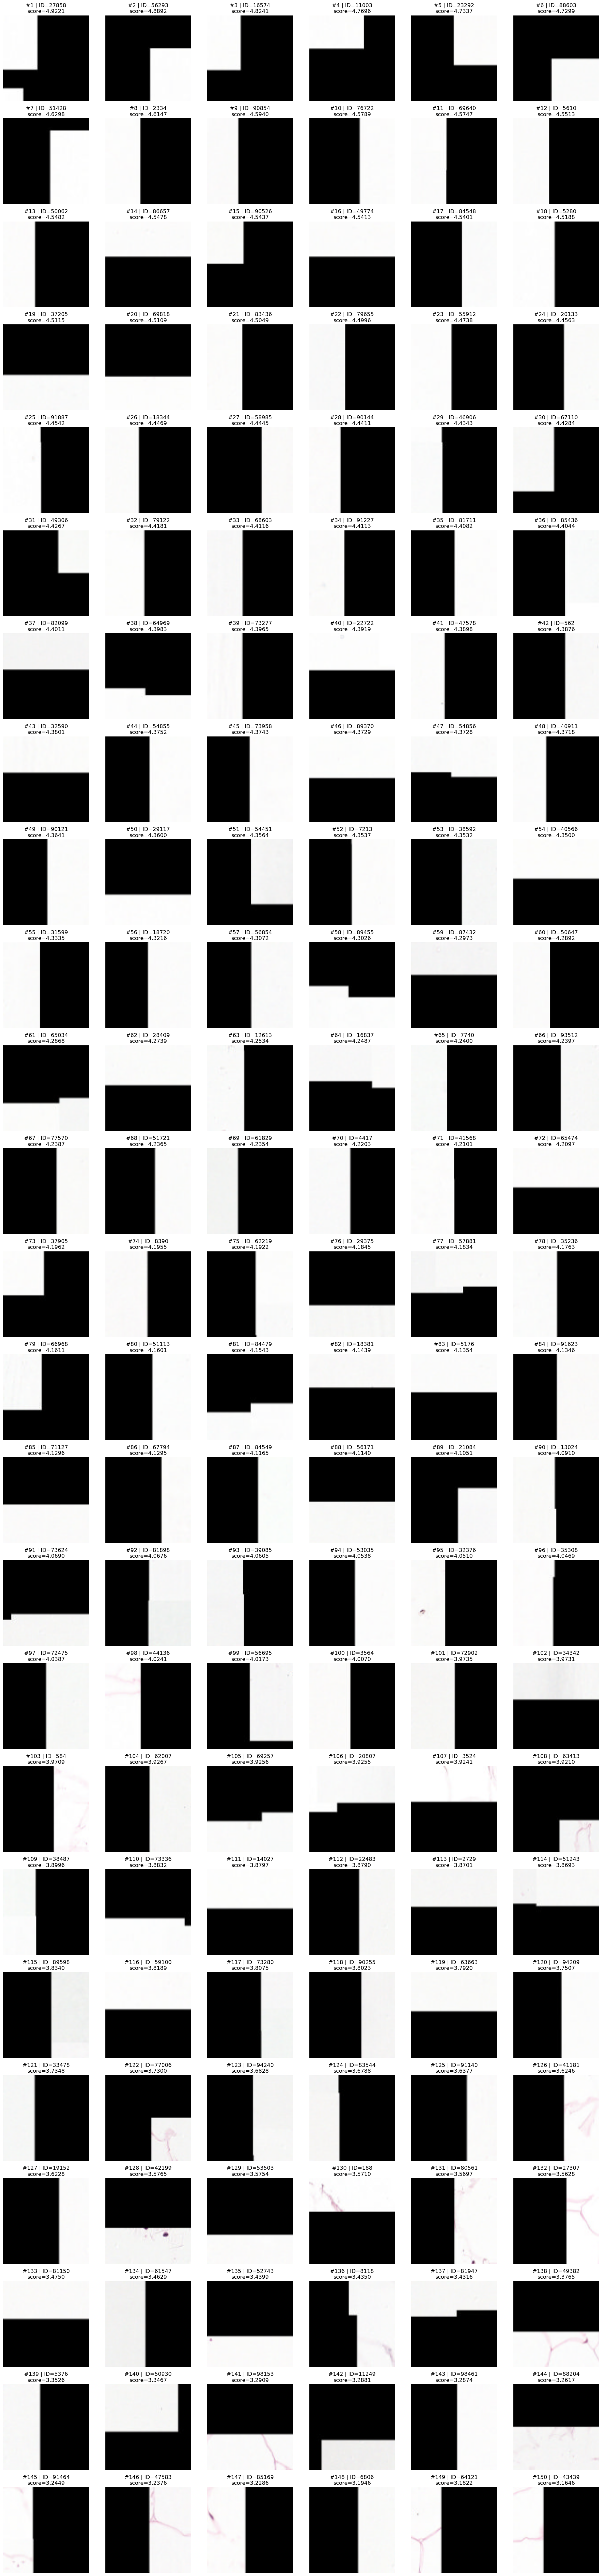

,patch_id,label,score,is_outlier,center_id
0,27858,0.0,4.922115,True,0
1,56293,0.0,4.889204,True,0
2,16574,0.0,4.824097,True,3
3,11003,0.0,4.769627,True,3
4,23292,0.0,4.733679,True,0
5,88603,0.0,4.729885,True,0
6,51428,0.0,4.629847,True,0
7,2334,0.0,4.614741,True,0
8,90854,0.0,4.593989,True,3
9,76722,0.0,4.578906,True,0


val
Outliers flagged by method (split=val): 449 / 34904
Visualization slice: ranks 1-150 (150 patch(es))


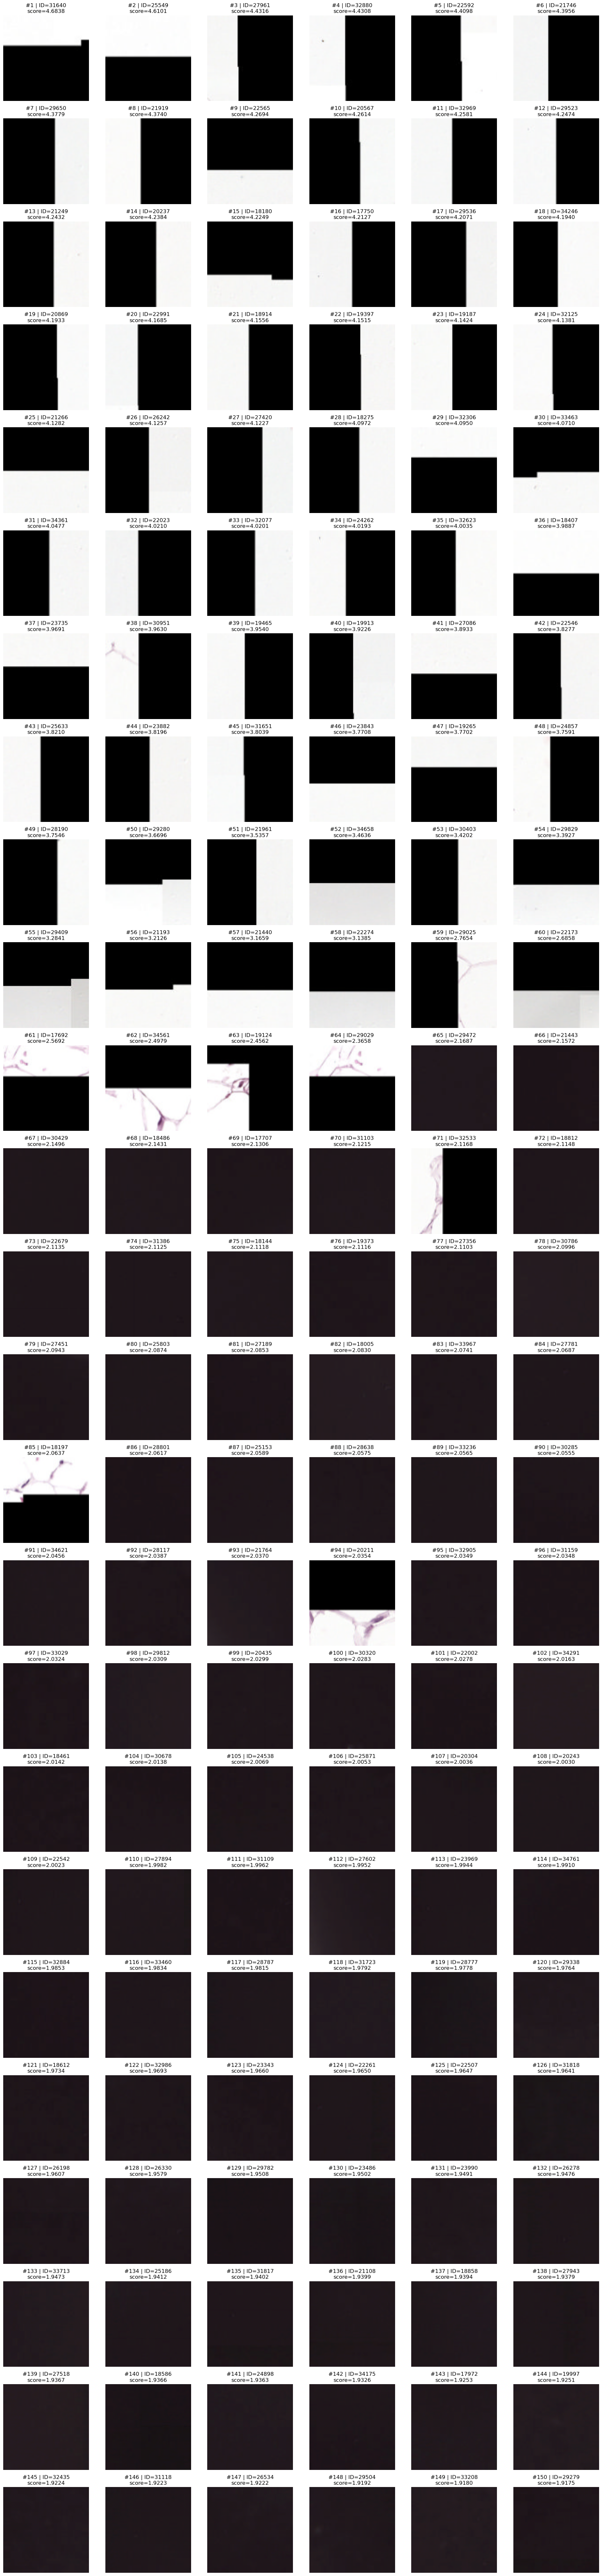

,patch_id,label,score,is_outlier,center_id
0,31640,0.0,4.683793,True,1
1,25549,0.0,4.610068,True,1
2,27961,0.0,4.431618,True,1
3,32880,0.0,4.430829,True,1
4,22592,0.0,4.409832,True,1
5,21746,0.0,4.395592,True,1
6,29650,0.0,4.377879,True,1
7,21919,0.0,4.373987,True,1
8,22565,0.0,4.269439,True,1
9,20567,0.0,4.261440,True,1


test
Outliers flagged by method (split=test): 30 / 85054
Visualization slice: ranks 1-150 (30 patch(es))


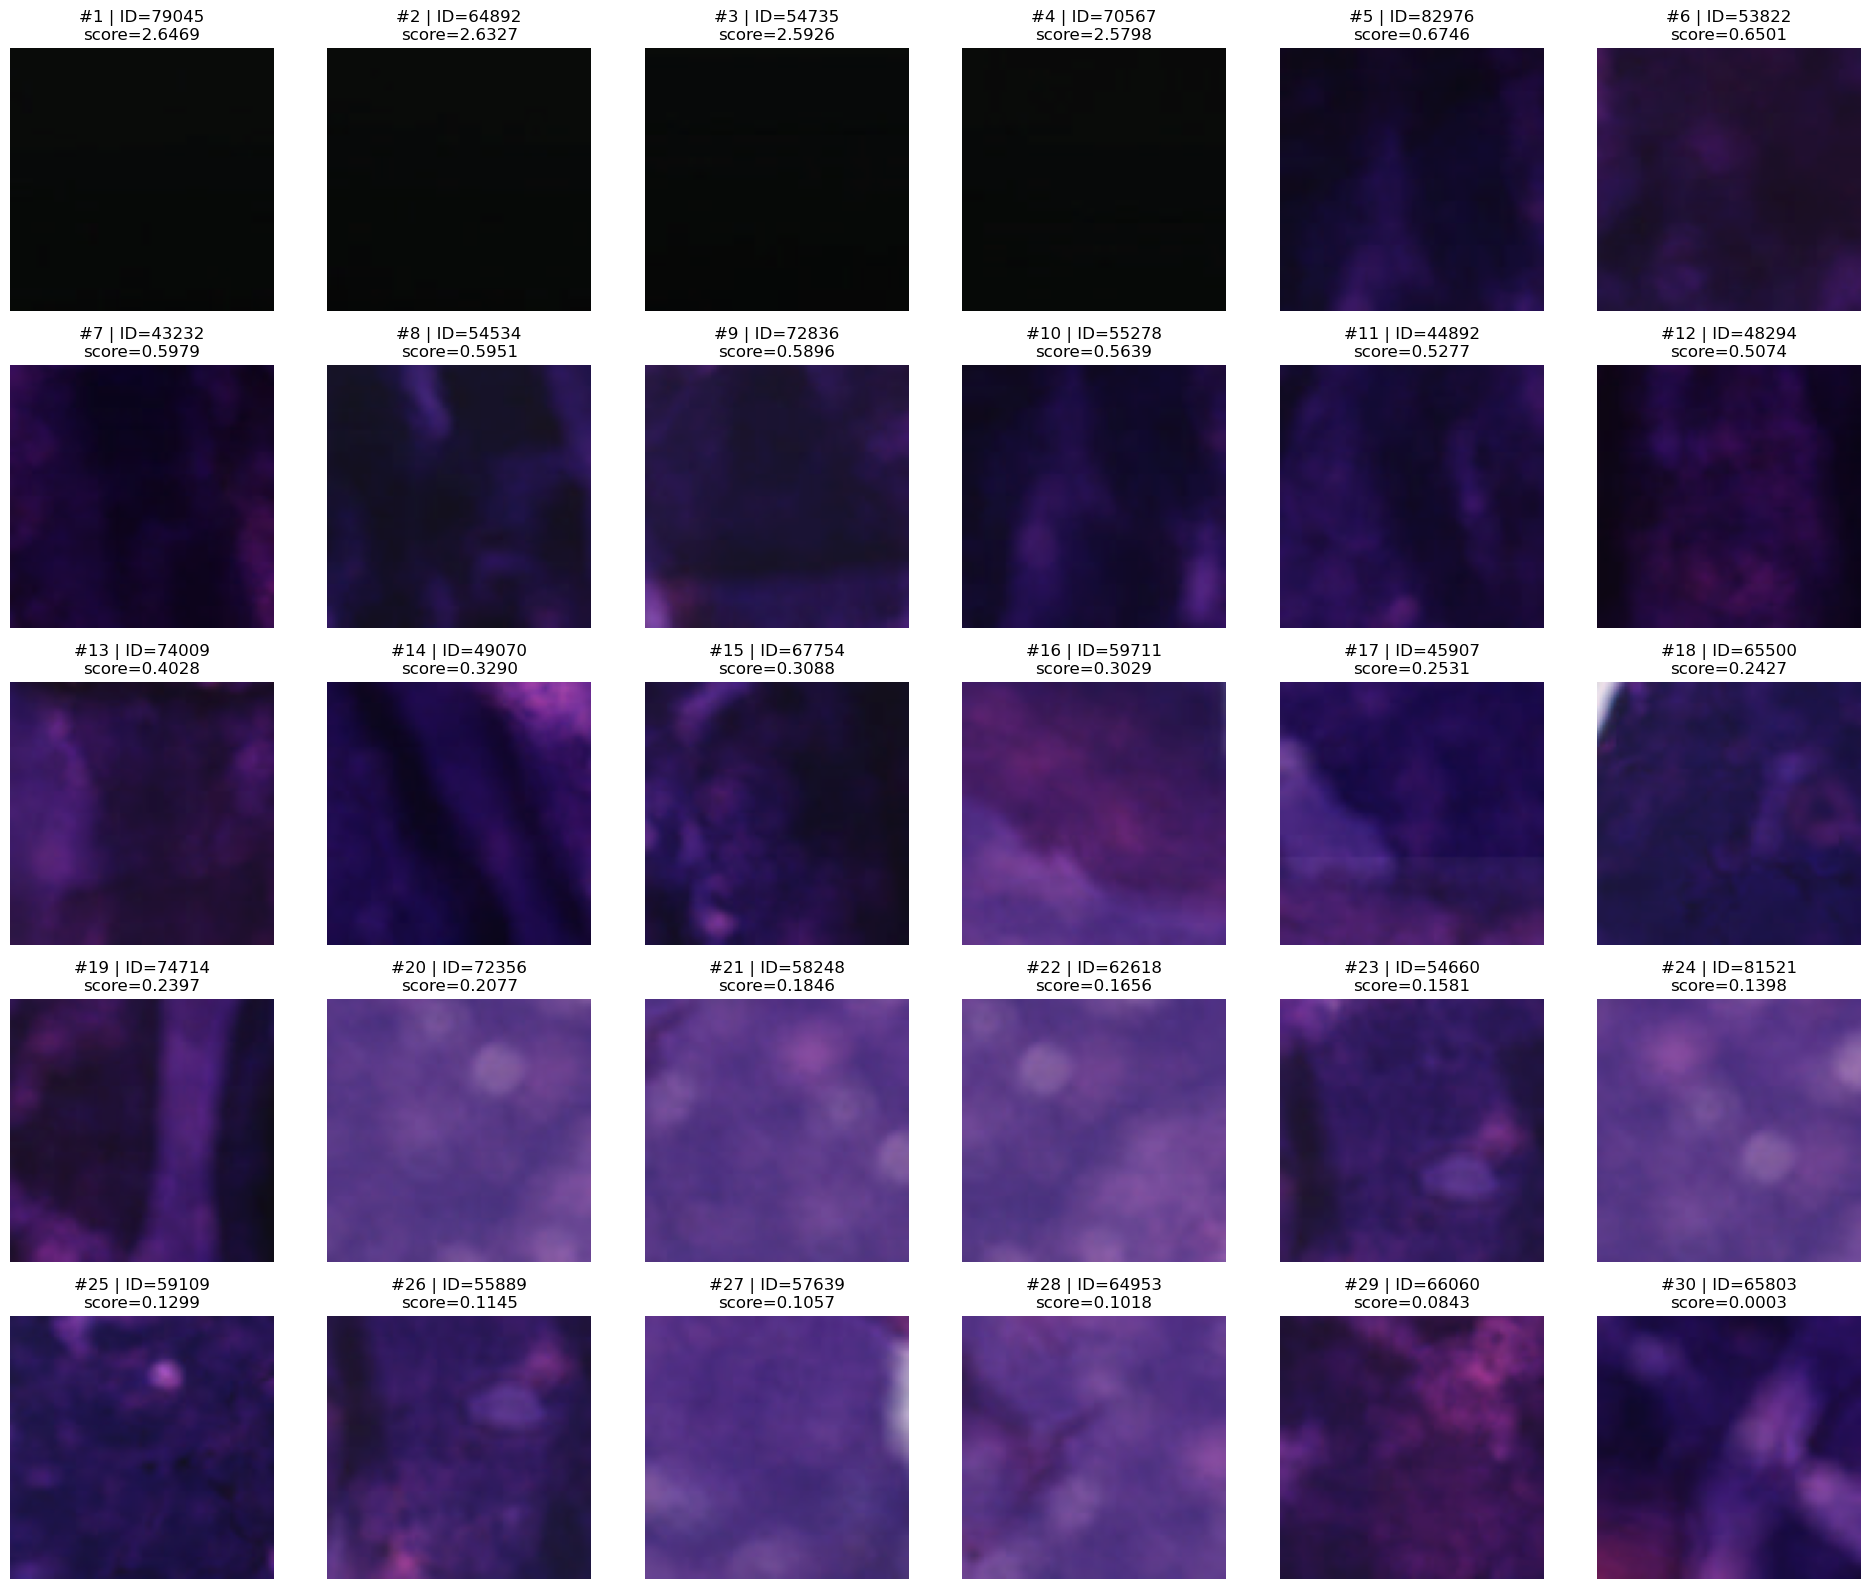

,patch_id,score,is_outlier,center_id
0,79045,2.646925,True,-1
1,64892,2.632662,True,-1
2,54735,2.592643,True,-1
3,70567,2.579798,True,-1
4,82976,0.674574,True,-1
5,53822,0.650130,True,-1
6,43232,0.597878,True,-1
7,54534,0.595148,True,-1
8,72836,0.589586,True,-1
9,55278,0.563924,True,-1


In [10]:
# ajouter une condition + 50% noir ou (le truc de couleur mais avec un gradient qui doit etre plus faible pcq tache rose tres segmente sur blanc est selectionné)

# Visual inspection examples (worst first)
min_k = 1
top_k = 150
method_name = 'method_c_color_texture_grid_cfg8' # method_a_extremes, method_b_od_texture, method_c_color_texture
print('train')
_ = visualize_outliers(
    method_name=method_name,
    split_name='train',
    out_dir=RUN_OPTIONS.out_dir,
    min_k= min_k,
    top_k=top_k,
    only_flagged=True,
    descending=True,
)
print('val')
_ = visualize_outliers(
    method_name=method_name,
    split_name='val',
    out_dir=RUN_OPTIONS.out_dir,
    min_k= min_k,
    top_k=top_k,
    only_flagged=True,
    descending=True,
)
print('test')
_ = visualize_outliers(
    method_name=method_name,
    split_name='test',
    out_dir=RUN_OPTIONS.out_dir,
    min_k= min_k,
    top_k=top_k,
    only_flagged=True,
    descending=True,
)

In [16]:
# Inspect one raw patch: read only from HDF5 (no read_patch / no pipeline).
# `raw` is exactly the dataset array; display uses a separate `disp` view for CHW→HWC.
import matplotlib.pyplot as plt

mode = "test"  # "train" | "val" | "test"
patch_id = "1"  # str, same key as in the H5 file

path_map = {
    "train": SPLIT_PATHS.train,
    "val": SPLIT_PATHS.val,
    "test": SPLIT_PATHS.test,
}
if mode not in path_map:
    raise ValueError(f"mode must be one of {list(path_map)}, got {mode!r}")

h5_path = path_map[mode]
print(f"{mode}: {h5_path} | id={patch_id}")

with h5py.File(h5_path, "r") as f:
    if patch_id not in f:
        raise KeyError(f"ID {patch_id!r} not in {h5_path}. Example keys: {list(f.keys())[:5]} ...")

    raw = np.array(f[patch_id]["img"])

    center = -1
    if "metadata" in f[patch_id]:
        md = np.array(f[patch_id]["metadata"]).reshape(-1)
        if md.size > 0:
            center = int(md[0])

print("raw shape:", raw.shape, "dtype:", raw.dtype, "min:", float(np.nanmin(raw)), "max:", float(np.nanmax(raw)))

if raw.ndim != 3:
    raise ValueError(f"Unexpected raw shape for ID {patch_id}: {raw.shape}")

disp = raw
if raw.shape[0] in (1, 3):
    disp = np.moveaxis(raw, 0, -1)
if disp.shape[-1] == 1:
    disp = np.repeat(disp, repeats=3, axis=-1)

plt.figure(figsize=(4, 4))
plt.imshow(disp)
plt.title(f"{mode} | id={patch_id} | center={center}")
plt.axis("off")
plt.show()

test: test.h5 | id=1
raw shape: (3, 96, 96) dtype: float16 min: 0.0902099609375 max: 0.99609375


ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 400x400 with 1 Axes>

In [17]:
# # Manual review examples
# # 1) Save decisions after visual inspection
# review_path = save_manual_review(
#     method_name='method_b_od_texture',
#     split_name='train',
#     out_dir=RUN_OPTIONS.out_dir,
#     keep_ids=['123', '456'],      # false positives to keep
#     remove_ids=['789'],           # additional IDs to force as outlier
#     note='manual validation pass 1',
# )
# print('Review file:', review_path)

# # 2) Apply review decisions and save updated final labels
# scores_final = apply_manual_review(
#     method_name='method_b_od_texture',
#     split_name='train',
#     out_dir=RUN_OPTIONS.out_dir,
# )
# display(scores_final.head())

In [18]:
# --- CPU / thread budget (logical processors) ---
import os

print('os.cpu_count():', os.cpu_count())

try:
    import multiprocessing as mp

    print('mp.cpu_count():', mp.cpu_count())
except Exception as e:
    print('mp.cpu_count() unavailable:', e)

try:
    import psutil

    print('psutil logical:', psutil.cpu_count(logical=True))
    print('psutil physical:', psutil.cpu_count(logical=False))
except ImportError:
    print('psutil not installed (optional: pip install psutil)')

os.cpu_count(): 8
mp.cpu_count(): 8
psutil logical: 8
psutil physical: 8
